In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.checkpoint.memory import MemorySaver
from dotenv import load_dotenv

load_dotenv()

model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash-lite",
    temperature=1.0
)

In [2]:
# We use MessagesState, which already has the 'messages' key with a reducer.
def call_model(state: MessagesState):
    """
    The core agent node. It takes the current state (conversation history),
    calls the LLM, and returns the new AI message.
    """
    response = model.invoke(state["messages"])
    # We return a dict with the key 'messages'. The reducer will append this to the history.
    return {"messages": [response]}

In [3]:
workflow = StateGraph(MessagesState)

workflow.add_node("agent", call_model)

workflow.add_edge(START, "agent")
workflow.add_edge("agent", END)

In [4]:
# MemorySaver allows the graph to retain conversation history across specific thread_ids.
checkpointer = MemorySaver()
app = workflow.compile(checkpointer=checkpointer)

In [5]:
def run_interactive_session():
    print("Bot is ready! Type 'quit' to exit.")

    # This thread_id isolates this specific conversation history
    config = {"configurable": {"thread_id": "session_1"}}

    while True:
        user_input = input("You: ")
        if user_input.lower() in ["quit", "exit"]:
            print("Goodbye!")
            break

        # We allow the user to see the streaming output or just the final result.
        # Here we stream the updates to the state.
        events = app.stream(
            {"messages": [HumanMessage(content=user_input)]},
            config=config,
            stream_mode="values"
        )

        for event in events:
            if "messages" in event:
                last_msg = event["messages"][-1]
                if last_msg.type == "ai":
                    print(f"Agent: {last_msg.content}")

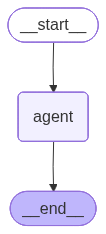

In [6]:
try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [7]:
run_interactive_session()

Bot is ready! Type 'quit' to exit.
Agent: I can:

Process text, generate content, translate languages, answer questions.
Agent: I can also:

Summarize information, write different kinds of creative content, assist with brainstorming.
Goodbye!
